In [3]:
pip install minisom

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13095 sha256=18cb02cbc0701809361918b3022f4d28b797aad30074abf242dc3241be6daa81
  Stored in directory: c:\users\kambl\appdata\local\pip\cache\wheels\84\35\b8\48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'minisom' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'minisom'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install minisom


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from minisom import MiniSom

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from tensorflow.keras.datasets import mnist

In [7]:
# Load MNIST Dataset
(x_train, y_train), (_, _) = mnist.load_data()

# Select One Image
image = x_train[0]

# Normalize Image
image = image / 255.0

In [8]:
# Convert Image into Vectors
data = image.reshape(-1, 1)

# Cell 4 : Create SOM Model

In [9]:
# Create SOM
som = MiniSom(

    x=8,
    y=8,

    input_len=1,

    sigma=1.0,

    learning_rate=0.5
)

# Cell 5 : Train SOM

In [10]:
# Train SOM
som.train_random(data, 100)

# Cell 6 : Compress Image

In [11]:
# Compress Image
compressed = []

for pixel in data:

    # Find Winning Neuron
    winner = som.winner(pixel)

    # Get Weight Value
    value = som.get_weights()[winner][0]

    compressed.append(value)

# Reshape Image
compressed_image = np.array(compressed).reshape(image.shape)

# Cell 7 : Show Images

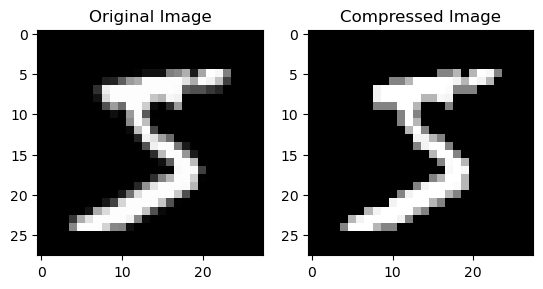

In [12]:
# Original Image
plt.subplot(1,2,1)

plt.imshow(image, cmap='gray')

plt.title("Original Image")


# Compressed Image
plt.subplot(1,2,2)

plt.imshow(compressed_image, cmap='gray')

plt.title("Compressed Image")

plt.show()